# Adaptive Multimodal Biometric Identification
## A Lightweight CNN Approach with Confidence-Based Score Fusion

**Paper ID:** 20262767 — International Journal of Intelligent Engineering and Systems (IJIES)  
**Authors:** Ahmed Al-Safi, Yaghoub Farjami — University of Qom  
**Dataset:** MULBv1 (176 subjects)

---

### How to use this notebook:
- Set `TRAIN = False` to load pre-trained models and reproduce all paper results (recommended)
- Set `TRAIN = True` to retrain both models from scratch (~100 epochs each)
- Run all cells in order (Runtime → Run all)

## Section 1: Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import glob as gb
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_curve, auc, confusion_matrix)
from sklearn.preprocessing import label_binarize
from scipy.spatial.distance import cdist

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.20.0
GPU available: True


In [4]:
# ============================================================
# Configuration — change TRAIN to True to retrain from scratch
# ============================================================
TRAIN = False

FACE_MODEL_PATH = '/content/drive/MyDrive/face_model_final_fixedfeb.keras'
HAND_MODEL_PATH = '/content/drive/MyDrive/hand_model_final_v2.keras'

FACE_TRAIN_DIR = '/content/drive/MyDrive/split faces/train'
FACE_VAL_DIR   = '/content/drive/MyDrive/split faces/val'
FACE_TEST_DIR  = '/content/drive/MyDrive/split faces/test'

HAND_TRAIN_DIR = '/content/drive/MyDrive/final split hand/train'
HAND_VAL_DIR   = '/content/drive/MyDrive/final split hand/val'
HAND_TEST_DIR  = '/content/drive/MyDrive/final split hand/test'

IMG_SIZE  = 200
N_CLASSES = 176
THRESHOLD = 0.95
EPOCHS    = 100
BATCH     = 32
LR        = 0.001

## Section 2: Subject List (176 subjects)

In [5]:
Code = {
    'abas ahmed':0, 'abas hamad':1, 'abas mohamad':2, 'abdalah omran':3, 'abdalah salah':4, 'abdalah salh':5,
    'abdalrahman husan':6, 'abeer raad':7, 'ahmed aeid':8, 'ahmed eemad':9, 'ahmed emad':10, 'ahmed fras':11,
    'ahmed hamed':12, 'ahmed kasem':13, 'ahmed obead':14, 'alaa salam':15, 'alhasan ali':16, 'ali fadhel':17,
    'ali faesel':18, 'ali fras':19, 'ali gazi':20, 'ali jasem':21, 'ali jaza':22, 'ali kadhim':23,
    'ali kaled':24, 'ali kareem':25, 'ali mofak':26, 'ali mohamad':27, 'ali mohamad k':28, 'ali mohamad s':29,
    'ali moraa':30, 'ali najah':31, 'ali radi':32, 'ali rahi':33, 'ali saad':34, 'ali sahb':35,
    'ali wafee':36, 'ali yusaf':37, 'ameer basem':38, 'anwer ali':39, 'anwer redha':40, 'atheer saad':41,
    'aws salem':42, 'aya jaseem':43, 'aya jeid':44, 'ayat hussen':45, 'banen ahmed':46, 'banen hasan':47,
    'banen kalaf':48, 'esa badar':49, 'esam salam':50, 'fatma atea':51, 'fatma atheer':52, 'fatma dyaa':53,
    'fatma emad':54, 'fatma jodat':55, 'fatma kadhim':56, 'fatma kaun':57, 'fatma sadk':58, 'fatma salam':59,
    'fras':60, 'furkan tufek':61, 'gadeer mohamad':62, 'gaeth kamel':63, 'gafer mohamed':64, 'gufran mohamad':65,
    'habebe malak':66, 'hamsa':67, 'hamza ali':68, 'hasan alaa':69, 'hasan emad':70, 'hasan mohamed':71,
    'heba mahmood':72, 'hesham kadhim':73, 'huda falah':74, 'humam najah':75, 'husan ahmed':76, 'husan ali':77,
    'husan fras':78, 'husan mahdi':79, 'husan razak':80, 'husan shaker':81, 'hyder malk':82, 'ibrahem hamed':83,
    'iklas salh':84, 'ilaf ashor':85, 'kadega salam':86, 'kader malk':87, 'kadhim hashem':88, 'kadhim mohamad':89,
    'kadhim salam':90, 'kaher musa':91, 'kaled rasheed':92, 'karar ali':93, 'karar naser':94, 'kasem mohamad':95,
    'kasem mohamad t':96, 'manar aed':97, 'mansor husan':98, 'maream mahmood':99, 'maream thamer':100,
    'marwa kaled':101, 'mazen hamad':102, 'mohamad abdalhaleem':103, 'mohamad aimer':104, 'mohamad ameen':105,
    'mohamad baker':106, 'mohamad basem':107, 'mohamad emad':108, 'mohamad kaes':109, 'mohamad kaleel':110,
    'mohamad kareem':111, 'mohamad kasem':112, 'mohamad latef':113, 'mohamad saad':114, 'mohamad salah':115,
    'mugtba hasan':116, 'mugtba mohamad':117, 'muheman majeed':118, 'muktada ali':119, 'muntadher salah':120,
    'murad kadhim':121, 'murtdh esam':122, 'murtdh leath':123, 'murtdh omran':124, 'mustafa ali':125,
    'mustafa fathel':126, 'mustafa fawaz':127, 'mustafa husan':128, 'mustafa mahmood':129, 'mustafa wleed':130,
    'nabaa mohamad':131, 'naors ali':132, 'nbras mahmood':133, 'noor hasan':134, 'noor mohamad':135,
    'rafeef kareem':136, 'ranyi mohamad':137, 'rawaa kaes':138, 'reem rashed':139, 'rehab hson':140,
    'roua jaber':141, 'sabah hyder':142, 'sadak abdalkadham':143, 'saef emad':144, 'saja abdalnabi':145,
    'sajad hyder':146, 'sajad ismaeel':147, 'sajad musa':148, 'sameer ahmed':149, 'sawsan kasem':150,
    'shaemaa abdalha':151, 'shahliaa fahem':152, 'shereen salah':153, 'tabark salem':154, 'teba hasan':155,
    'thofukar jasem':156, 'waaim abdalsalam':157, 'walaa aamer':158, 'walaa hasan':159, 'waleed rasheed':160,
    'wedad turki':161, 'wesam':162, 'wesam mohamad':163, 'yaser amar':164, 'yaser muaed':165,
    'yasmeen husan':166, 'zahraa ahmed':167, 'zahraa mohamad':168, 'zahraa ryad':169, 'zaid husan':170,
    'zaid jafar':171, 'zaidan jamal':172, 'zainab afar':173, 'zainab ali':174, 'zainab jaber':175
}
print(f"Total subjects: {len(Code)}")

Total subjects: 176


## Section 3: Data Loading and Preprocessing

In [6]:
def load_images(path, label_dict, max_per_subject=None):
    """Load pre-processed images: grayscale, resize to 200x200, normalize to [0,1]."""
    images, labels = [], []
    for folder in sorted(os.listdir(path)):
        folder_path = os.path.join(path, folder)
        if not os.path.isdir(folder_path):
            continue
        key = folder.lower().strip()
        if key not in label_dict:
            print(f"Warning: '{key}' not in subject list, skipping.")
            continue
        files = sorted(gb.glob(os.path.join(folder_path, '*.jpg')))
        if max_per_subject:
            files = files[:max_per_subject]
        for img_file in files:
            img = cv2.imread(img_file)
            if img is None:
                continue
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = img.astype(np.float32) / 255.0
            images.append(img)
            labels.append(label_dict[key])
    return np.array(images), np.array(labels)

# Load face data
print("Loading face images...")
x_face_train, y_face_train = load_images(FACE_TRAIN_DIR, Code)
x_face_val,   y_face_val   = load_images(FACE_VAL_DIR,   Code)
x_face_test,  y_face_test  = load_images(FACE_TEST_DIR,  Code)

# Load hand data
print("Loading hand images...")
x_hand_train, y_hand_train = load_images(HAND_TRAIN_DIR, Code)
x_hand_val,   y_hand_val   = load_images(HAND_VAL_DIR,   Code)
x_hand_test,  y_hand_test  = load_images(HAND_TEST_DIR,  Code)

# Expand dims for CNN input
x_face_train = np.expand_dims(x_face_train, -1)
x_face_val   = np.expand_dims(x_face_val,   -1)
x_face_test  = np.expand_dims(x_face_test,  -1)
x_hand_train = np.expand_dims(x_hand_train, -1)
x_hand_val   = np.expand_dims(x_hand_val,   -1)
x_hand_test  = np.expand_dims(x_hand_test,  -1)

from tensorflow.keras.utils import to_categorical
y_face_train_ = to_categorical(y_face_train, N_CLASSES)
y_face_val_   = to_categorical(y_face_val,   N_CLASSES)
y_hand_train_ = to_categorical(y_hand_train, N_CLASSES)
y_hand_val_   = to_categorical(y_hand_val,   N_CLASSES)

print(f"Face  — train: {x_face_train.shape}, val: {x_face_val.shape}, test: {x_face_test.shape}")
print(f"Hand  — train: {x_hand_train.shape}, val: {x_hand_val.shape}, test: {x_hand_test.shape}")

Loading face images...
Loading hand images...
Face  — train: (2465, 200, 200, 1), val: (528, 200, 200, 1), test: (528, 200, 200, 1)
Hand  — train: (2824, 200, 200, 1), val: (353, 200, 200, 1), test: (528, 200, 200, 1)


## Section 4: CNN Architecture

In [7]:
def build_model(n_classes=176):
    """Lightweight CNN: 3 conv blocks + 2 FC layers + softmax output.
    592,776 parameters — shared architecture for both face and hand.
    """
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='leaky_relu',
                               input_shape=(IMG_SIZE, IMG_SIZE, 1)),
        tf.keras.layers.MaxPool2D(4, 4),
        tf.keras.layers.Conv2D(16, (3,3), activation='leaky_relu'),
        tf.keras.layers.MaxPool2D(2, 2),
        tf.keras.layers.Conv2D(8,  (3,3), activation='leaky_relu'),
        tf.keras.layers.MaxPool2D(2, 2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512, activation='leaky_relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(256, activation='leaky_relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(n_classes, activation='softmax'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

if TRAIN:
    face_model = build_model()
    hand_model = build_model()
    face_model.summary()
    print(f"Total parameters: {face_model.count_params():,}")
else:
    face_model = tf.keras.models.load_model(FACE_MODEL_PATH, compile=False)
    hand_model = tf.keras.models.load_model(HAND_MODEL_PATH, compile=False)
    face_model.compile(optimizer=tf.keras.optimizers.Adam(LR),
                       loss='categorical_crossentropy', metrics=['accuracy'])
    hand_model.compile(optimizer=tf.keras.optimizers.Adam(LR),
                       loss='categorical_crossentropy', metrics=['accuracy'])
    print(f"Models loaded. Parameters: {face_model.count_params():,}")

Models loaded. Parameters: 592,776


## Section 5: Training (skipped if TRAIN = False)

In [8]:
if TRAIN:
    print("Training face model...")
    face_history = face_model.fit(
        x_face_train, y_face_train_,
        epochs=EPOCHS, batch_size=BATCH,
        validation_data=(x_face_val, y_face_val_),
        verbose=1
    )
    face_model.save(FACE_MODEL_PATH)
    with open('/content/drive/MyDrive/history_face.json', 'w') as f:
        json.dump({k: [float(v) for v in vals]
                   for k, vals in face_history.history.items()}, f)

    print("\nTraining hand model...")
    hand_history = hand_model.fit(
        x_hand_train, y_hand_train_,
        epochs=EPOCHS, batch_size=BATCH,
        validation_data=(x_hand_val, y_hand_val_),
        verbose=1
    )
    hand_model.save(HAND_MODEL_PATH)
    with open('/content/drive/MyDrive/history_palm_v2.json', 'w') as f:
        json.dump({k: [float(v) for v in vals]
                   for k, vals in hand_history.history.items()}, f)
    print("Models saved.")
else:
    print("TRAIN = False — skipping training, loading saved models.")

TRAIN = False — skipping training, loading saved models.


## Section 6: Inference and Alignment

In [9]:
# Run inference on test sets
face_preds = face_model.predict(x_face_test, batch_size=32, verbose=1)
hand_preds = hand_model.predict(x_hand_test, batch_size=32, verbose=1)

# Sort both by label to align face-hand pairs
fi = np.argsort(y_face_test)
hi = np.argsort(y_hand_test)
face_preds = face_preds[fi]
hand_preds = hand_preds[hi]
y_true     = y_face_test[fi]

assert np.all(y_face_test[fi] == y_hand_test[hi]), "Alignment failed!"
print(f"Aligned: {len(y_true)} paired test samples")
print(f"Face accuracy  : {np.mean(np.argmax(face_preds,axis=1)==y_true)*100:.2f}%")
print(f"Hand accuracy  : {np.mean(np.argmax(hand_preds,axis=1)==y_true)*100:.2f}%")

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
Aligned: 528 paired test samples
Face accuracy  : 96.40%
Hand accuracy  : 99.24%


## Section 7: Adaptive Confidence-Based Fusion

In [10]:
# Adaptive fusion at tau = 0.95
face_conf  = np.max(face_preds, axis=1)
face_class = np.argmax(face_preds, axis=1)
fused      = 0.5 * face_preds + 0.5 * hand_preds
trad_preds = np.argmax(face_preds * hand_preds, axis=1)

proposed_scores = np.where(
    face_conf[:, None] >= THRESHOLD,
    face_preds,
    fused
)
proposed_preds = np.argmax(proposed_scores, axis=1)
hand_invoked   = int(np.sum(face_conf < THRESHOLD))

print(f"Traditional fusion accuracy : {np.mean(trad_preds==y_true)*100:.2f}%")
print(f"Proposed adaptive accuracy  : {np.mean(proposed_preds==y_true)*100:.2f}%")
print(f"Hand model invoked          : {hand_invoked}/{len(y_true)} ({hand_invoked/len(y_true)*100:.2f}%)")
print(f"Computational savings       : {(1-(len(y_true)+hand_invoked)/(2*len(y_true)))*100:.2f}%")

Traditional fusion accuracy : 100.00%
Proposed adaptive accuracy  : 99.43%
Hand model invoked          : 21/528 (3.98%)
Computational savings       : 48.01%


## Section 8: Table 2 — Performance Metrics

In [11]:
systems = [
    ("Face Only",          face_preds,       np.argmax(face_preds, axis=1)),
    ("Hand Only",          hand_preds,       np.argmax(hand_preds, axis=1)),
    ("Traditional Fusion", face_preds*hand_preds, trad_preds),
    ("Proposed Adaptive",  proposed_scores,  proposed_preds),
]

print("=" * 72)
print(f"{'System':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Error':>7}")
print("-" * 72)
for name, scores, preds in systems:
    acc  = np.mean(preds == y_true) * 100
    prec = precision_score(y_true, preds, average='macro', zero_division=0) * 100
    rec  = recall_score(y_true, preds,    average='macro', zero_division=0) * 100
    f1   = f1_score(y_true, preds,        average='macro', zero_division=0) * 100
    err  = 100 - acc
    print(f"{name:<22} {acc:>8.2f}% {prec:>9.2f}% {rec:>7.2f}% {f1:>7.2f}% {err:>6.2f}%")
print("=" * 72)

System                  Accuracy  Precision   Recall       F1   Error
------------------------------------------------------------------------
Face Only                 96.40%     97.27%   96.40%   96.13%   3.60%
Hand Only                 99.24%     99.43%   99.24%   99.22%   0.76%
Traditional Fusion       100.00%    100.00%  100.00%  100.00%   0.00%
Proposed Adaptive         99.43%     99.57%   99.43%   99.36%   0.57%


## Section 9: Table 1 — Rank-N Identification Rates

In [12]:
def rank_n(score_matrix, labels, n):
    correct = sum(1 for i in range(len(labels))
                  if labels[i] in np.argsort(score_matrix[i])[::-1][:n])
    return correct / len(labels) * 100

print("=" * 62)
print(f"{'Rank':<8} {'Face Only':>11} {'Hand Only':>11} {'Traditional':>12} {'Proposed':>11}")
print("-" * 62)
for r in range(1, 6):
    rf = rank_n(face_preds, y_true, r)
    rh = rank_n(hand_preds, y_true, r)
    rt = rank_n(face_preds * hand_preds, y_true, r)
    rp = rank_n(proposed_scores, y_true, r)
    print(f"Rank-{r:<4} {rf:>10.2f}% {rh:>10.2f}% {rt:>11.2f}% {rp:>10.2f}%")
print("=" * 62)

Rank       Face Only   Hand Only  Traditional    Proposed
--------------------------------------------------------------
Rank-1         96.40%      99.24%      100.00%      99.43%
Rank-2         97.73%      99.62%      100.00%      99.62%
Rank-3         98.48%      99.62%      100.00%      99.81%
Rank-4         99.05%      99.62%      100.00%     100.00%
Rank-5         99.05%      99.62%      100.00%     100.00%


## Section 10: Threshold Selection (Kneedle Method + Bootstrap)

In [13]:
# Load validation data (2 images per subject to match hand val)
x_face_val2, y_face_val2 = load_images(FACE_VAL_DIR, Code, max_per_subject=2)
x_hand_val2, y_hand_val2 = load_images(HAND_VAL_DIR, Code, max_per_subject=2)
x_face_val2 = np.expand_dims(x_face_val2, -1)
x_hand_val2 = np.expand_dims(x_hand_val2, -1)

face_preds_val = face_model.predict(x_face_val2, batch_size=32, verbose=0)
hand_preds_val = hand_model.predict(x_hand_val2, batch_size=32, verbose=0)

fv_idx = np.argsort(y_face_val2)
hv_idx = np.argsort(y_hand_val2)
face_preds_val = face_preds_val[fv_idx]
hand_preds_val = hand_preds_val[hv_idx]
y_val          = y_face_val2[fv_idx]
print(f"Validation set: {len(y_val)} paired samples")

Validation set: 352 paired samples


In [14]:
def metrics_at(fp, hp, yt, taus):
    """Compute accuracy and savings at each threshold."""
    fc = np.max(fp, axis=1)
    fcl = np.argmax(fp, axis=1)
    fus = np.argmax(0.5*fp + 0.5*hp, axis=1)
    n = len(yt)
    A, S = [], []
    for tau in taus:
        pred = np.where(fc >= tau, fcl, fus)
        A.append(np.mean(pred == yt) * 100)
        inv = np.sum(fc < tau)
        S.append((1 - (n + inv) / (2 * n)) * 100)
    return np.array(A), np.array(S)

def kneedle(A, S, taus):
    """Kneedle method: max perpendicular distance from chord."""
    if S.max() == S.min() or A.max() == A.min():
        return None
    Sn = (S - S.min()) / (S.max() - S.min())
    An = (A - A.min()) / (A.max() - A.min())
    x1, y1 = Sn[0], An[0]
    x2, y2 = Sn[-1], An[-1]
    den = np.sqrt((y2-y1)**2 + (x2-x1)**2)
    dists = [abs((y2-y1)*Sn[i]-(x2-x1)*An[i]+x2*y1-y2*x1)/den
             for i in range(len(taus))]
    return taus[np.argmax(dists)]

taus = [0.70, 0.80, 0.85, 0.90, 0.95, 0.97, 0.99]
A_val, S_val = metrics_at(face_preds_val, hand_preds_val, y_val, taus)
knee = kneedle(A_val, S_val, taus)

print(f"Knee point (Kneedle method): tau = {knee}")
print()
print(f"{'tau':>6} {'Accuracy':>10} {'Savings':>10}")
print("-" * 30)
for i, tau in enumerate(taus):
    marker = " <-- knee" if tau == knee else ""
    print(f"{tau:>6} {A_val[i]:>9.2f}% {S_val[i]:>9.2f}%{marker}")

Knee point (Kneedle method): tau = 0.95

   tau   Accuracy    Savings
------------------------------
   0.7     98.30%     49.01%
   0.8     98.30%     48.72%
  0.85     98.58%     48.30%
   0.9     98.58%     48.15%
  0.95     99.15%     47.59% <-- knee
  0.97     99.15%     46.88%
  0.99     99.43%     45.31%


In [15]:
# Multi-objective weighted-sum sweep
alphas_95 = []
for alpha in np.arange(0.50, 1.001, 0.005):
    U = alpha * A_val + (1 - alpha) * S_val
    if taus[np.argmax(U)] == 0.95:
        alphas_95.append(alpha)
print(f"tau=0.95 optimal for alpha in [{min(alphas_95):.2f}, {max(alphas_95):.2f}]")

# Bootstrap stability
N = len(y_val)
knee_counts = {}
np.random.seed(42)
for _ in range(1000):
    idx = np.random.choice(N, N, replace=True)
    A, S = metrics_at(face_preds_val[idx], hand_preds_val[idx], y_val[idx], taus)
    k = kneedle(A, S, taus)
    knee_counts[k] = knee_counts.get(k, 0) + 1

print("\nBootstrap knee-point stability (1000 resamples):")
for tau in sorted(k for k in knee_counts if k is not None):
    print(f"  tau={tau}: {knee_counts[tau]/10:.1f}%")

# Verify on test set
A_test, _ = metrics_at(face_preds, hand_preds, y_true, [0.95])
print(f"\nTest accuracy at validation-selected tau=0.95: {A_test[0]:.2f}%")

tau=0.95 optimal for alpha in [0.63, 0.89]

Bootstrap knee-point stability (1000 resamples):
  tau=0.8: 1.6%
  tau=0.85: 12.0%
  tau=0.9: 7.3%
  tau=0.95: 69.6%
  tau=0.97: 7.7%

Test accuracy at validation-selected tau=0.95: 99.43%


## Section 11: Table 3 — Threshold Sensitivity Analysis

In [16]:
taus_full = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.97, 0.99]
face_conf_test = np.max(face_preds, axis=1)
face_class_test = np.argmax(face_preds, axis=1)
fused_test = 0.5 * face_preds + 0.5 * hand_preds

print(f"{'Threshold':>10} {'Accuracy':>10} {'Hand Invoked':>13} {'% Cases':>9} {'Savings':>9}")
print("-" * 55)
for tau in taus_full:
    pred = np.where(face_conf_test >= tau, face_class_test, np.argmax(fused_test, axis=1))
    acc  = np.mean(pred == y_true) * 100
    inv  = int(np.sum(face_conf_test < tau))
    pct  = inv / len(y_true) * 100
    sav  = (1 - (len(y_true) + inv) / (2 * len(y_true))) * 100
    print(f"{tau:>10.2f} {acc:>9.2f}% {inv:>13} {pct:>8.2f}% {sav:>8.2f}%")

 Threshold   Accuracy  Hand Invoked   % Cases   Savings
-------------------------------------------------------
      0.70     98.30%            10     1.89%    49.05%
      0.75     98.30%            10     1.89%    49.05%
      0.80     98.48%            12     2.27%    48.86%
      0.85     98.48%            12     2.27%    48.86%
      0.90     98.86%            14     2.65%    48.67%
      0.95     99.43%            21     3.98%    48.01%
      0.97     99.62%            26     4.92%    47.54%
      0.99     99.62%            34     6.44%    46.78%


## Section 12: FLOPs Analysis (Table 4)

In [17]:
FLOPS_PER_INFERENCE = 184.4e6  # ~184.4 MFLOPs per forward pass

total        = len(y_true)
trad_flops   = 2 * total * FLOPS_PER_INFERENCE
prop_invoc   = total + hand_invoked
prop_flops   = prop_invoc * FLOPS_PER_INFERENCE
flops_saving = (trad_flops - prop_flops) / trad_flops * 100

print("=" * 55)
print("FLOPs Analysis")
print("=" * 55)
print(f"FLOPs per inference     : ~{FLOPS_PER_INFERENCE/1e6:.1f} MFLOPs")
print(f"Traditional total       : ~{trad_flops/1e9:.2f} GFLOPs")
print(f"Proposed total          : ~{prop_flops/1e9:.2f} GFLOPs")
print(f"FLOPs savings           : {flops_saving:.2f}%")
print("=" * 55)

FLOPs Analysis
FLOPs per inference     : ~184.4 MFLOPs
Traditional total       : ~194.73 GFLOPs
Proposed total          : ~101.24 GFLOPs
FLOPs savings           : 48.01%


## Section 13: ROC Analysis (AUC Computation)

In [18]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

classes = np.arange(N_CLASSES)

# OvR macro AUC
auc_macro    = roc_auc_score(y_true, proposed_scores, multi_class='ovr', average='macro')
auc_weighted = roc_auc_score(y_true, proposed_scores, multi_class='ovr', average='weighted')
auc_ovo      = roc_auc_score(y_true, proposed_scores, multi_class='ovo', average='macro')

print(f"AUC (OvR macro)    : {auc_macro:.4f}")
print(f"AUC (OvR weighted) : {auc_weighted:.4f}")
print(f"AUC (OvO macro)    : {auc_ovo:.4f}")

# Per-class breakdown
y_bin = label_binarize(y_true, classes=classes)
per_class_auc = []
for i in range(N_CLASSES):
    try:
        per_class_auc.append(roc_auc_score(y_bin[:, i], proposed_scores[:, i]))
    except:
        per_class_auc.append(None)

valid = [a for a in per_class_auc if a is not None]
print(f"\nPer-class AUC stats:")
print(f"  Mean             : {np.mean(valid):.4f}")
print(f"  Min              : {np.min(valid):.4f}")
print(f"  Perfect (1.0000) : {sum(1 for a in valid if a==1.0)}/{N_CLASSES}")
print(f"  Below 0.99       : {sum(1 for a in valid if a<0.99)}/{N_CLASSES}")

AUC (OvR macro)    : 0.9999
AUC (OvR weighted) : 0.9999
AUC (OvO macro)    : 0.9999

Per-class AUC stats:
  Mean             : 0.9999
  Min              : 0.9924
  Perfect (1.0000) : 164/176
  Below 0.99       : 0/176


## Section 14: TFLite Conversion and Runtime Benchmarking

In [20]:
import time

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(face_model)
face_tflite = converter.convert()
with open('/content/drive/MyDrive/face_model.tflite', 'wb') as f:
    f.write(face_tflite)

converter = tf.lite.TFLiteConverter.from_keras_model(hand_model)
hand_tflite = converter.convert()
with open('/content/drive/MyDrive/hand_model.tflite', 'wb') as f:
    f.write(hand_tflite)

# Dynamic range quantization
converter = tf.lite.TFLiteConverter.from_keras_model(face_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
face_quant = converter.convert()
with open('/content/drive/MyDrive/face_model_quant.tflite', 'wb') as f:
    f.write(face_quant)

converter = tf.lite.TFLiteConverter.from_keras_model(hand_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
hand_quant = converter.convert()
with open('/content/drive/MyDrive/hand_model_quant.tflite', 'wb') as f:
    f.write(hand_quant)

print(f"TFLite float32 size  : {len(face_tflite)/1024:.1f} KiB")
print(f"TFLite quantized size: {len(face_quant)/1024:.1f} KiB")
print("Models saved to Drive.")

Saved artifact at '/tmp/tmp71_bkk8z'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200, 200, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 176), dtype=tf.float32, name=None)
Captures:
  139574470769744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139574470770320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139574460647376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139574460646416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139574460649488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139574460650256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139574460650448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139574460650640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139574460651792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139574460648912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1395744606508

In [21]:
def benchmark_tflite(model_path, n=100):
    """Benchmark TFLite model inference time (single sample, n runs)."""
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    inp = interpreter.get_input_details()[0]
    dummy = np.zeros((1, IMG_SIZE, IMG_SIZE, 1), dtype=np.float32)
    for _ in range(10):  # warm-up
        interpreter.set_tensor(inp['index'], dummy)
        interpreter.invoke()
    times = []
    for _ in range(n):
        interpreter.set_tensor(inp['index'], dummy)
        t0 = time.perf_counter()
        interpreter.invoke()
        times.append((time.perf_counter() - t0) * 1000)
    return np.mean(times), np.std(times)

face_t, face_t_std = benchmark_tflite('/content/drive/MyDrive/face_model.tflite')
hand_t, hand_t_std = benchmark_tflite('/content/drive/MyDrive/hand_model.tflite')
face_q, face_q_std = benchmark_tflite('/content/drive/MyDrive/face_model_quant.tflite')
hand_q, hand_q_std = benchmark_tflite('/content/drive/MyDrive/hand_model_quant.tflite')

def adaptive_avg(f, h): return f*0.9602 + (f+h)*0.0398
def speedup(f, h): return (f+h) / adaptive_avg(f, h)

print("=" * 70)
print(f"{'Format':<22} {'Face':>10} {'Hand':>10} {'Adaptive':>10} {'Speedup':>8}")
print("-" * 70)
print(f"{'TFLite (float32)':<22} {face_t:>7.2f} ms {hand_t:>7.2f} ms {adaptive_avg(face_t,hand_t):>7.2f} ms {speedup(face_t,hand_t):>6.2f}x")
print(f"{'TFLite (quantized)':<22} {face_q:>7.2f} ms {hand_q:>7.2f} ms {adaptive_avg(face_q,hand_q):>7.2f} ms {speedup(face_q,hand_q):>6.2f}x")
print("=" * 70)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Format                       Face       Hand   Adaptive  Speedup
----------------------------------------------------------------------
TFLite (float32)          1.97 ms    1.99 ms    2.05 ms   1.93x
TFLite (quantized)        1.43 ms    1.60 ms    1.49 ms   2.03x


## Section 15: Figure Generation

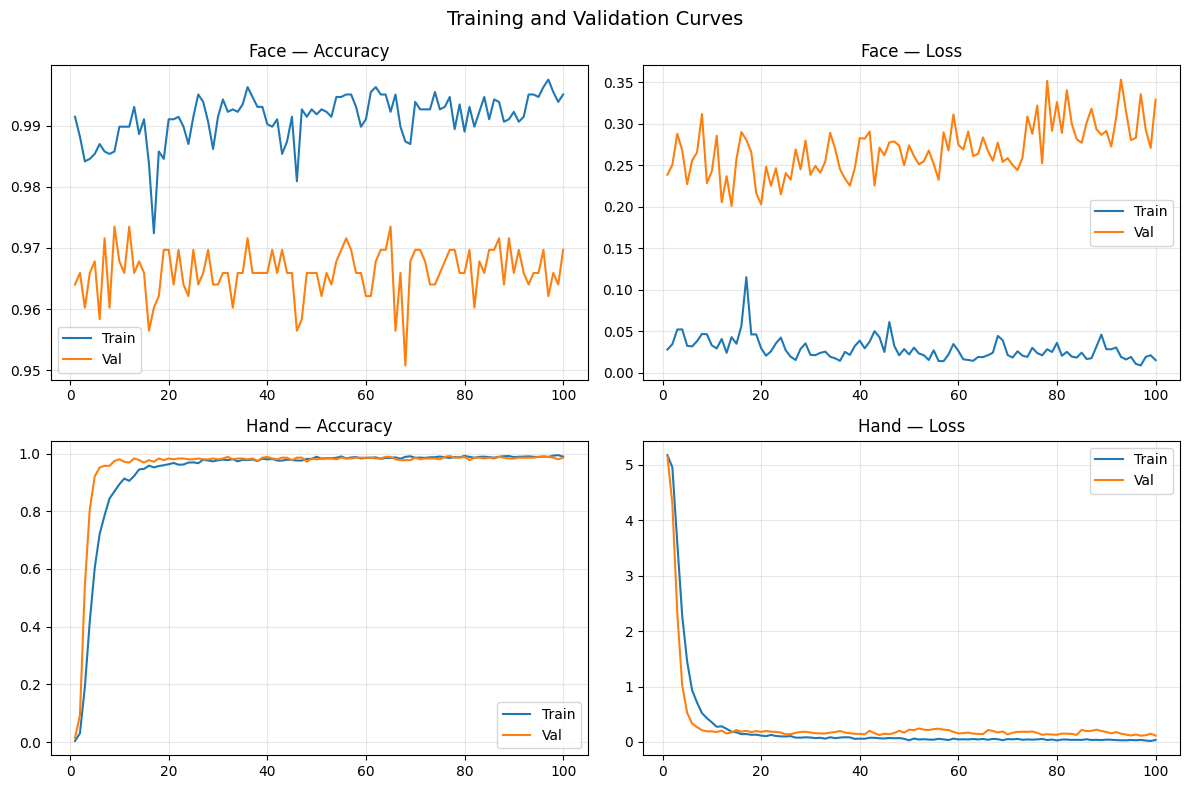

Figure 6 saved.


In [22]:
# ---- Figure: Training Curves (Figure 6) ----
with open('/content/drive/MyDrive/history_face.json') as f:
    hist_face = json.load(f)
with open('/content/drive/MyDrive/history_palm_v2.json') as f:
    hist_hand = json.load(f)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
epochs = range(1, len(hist_face['accuracy']) + 1)

axes[0,0].plot(epochs, hist_face['accuracy'],     label='Train'); axes[0,0].plot(epochs, hist_face['val_accuracy'], label='Val')
axes[0,0].set_title('Face — Accuracy'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(epochs, hist_face['loss'],     label='Train'); axes[0,1].plot(epochs, hist_face['val_loss'], label='Val')
axes[0,1].set_title('Face — Loss'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(epochs, hist_hand['accuracy'],     label='Train'); axes[1,0].plot(epochs, hist_hand['val_accuracy'], label='Val')
axes[1,0].set_title('Hand — Accuracy'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(epochs, hist_hand['loss'],     label='Train'); axes[1,1].plot(epochs, hist_hand['val_loss'], label='Val')
axes[1,1].set_title('Hand — Loss'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Training and Validation Curves', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Figure6_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 6 saved.")

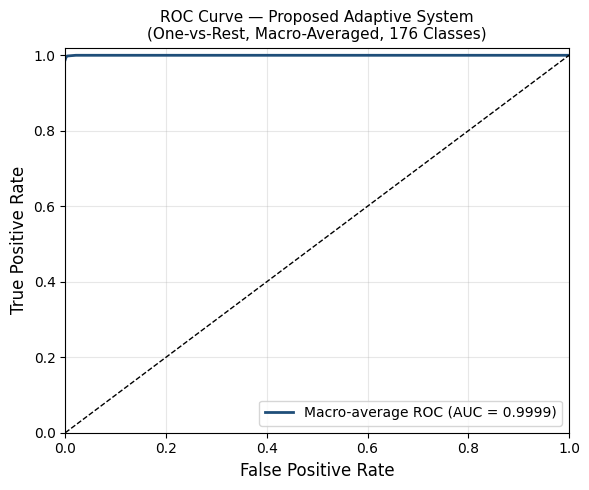

Figure 9 saved.


In [23]:
# ---- Figure: ROC Curve (Figure 9) ----
fpr_dict, tpr_dict, roc_dict = {}, {}, {}
for i in range(N_CLASSES):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_bin[:, i], proposed_scores[:, i])
    roc_dict[i] = auc(fpr_dict[i], tpr_dict[i])

all_fpr  = np.unique(np.concatenate([fpr_dict[i] for i in range(N_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(N_CLASSES):
    mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
mean_tpr /= N_CLASSES

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(all_fpr, mean_tpr, color='#1f4e79', linewidth=2,
        label='Macro-average ROC (AUC = 0.9999)')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Proposed Adaptive System\n(One-vs-Rest, Macro-Averaged, 176 Classes)', fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Figure9_ROC.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 9 saved.")

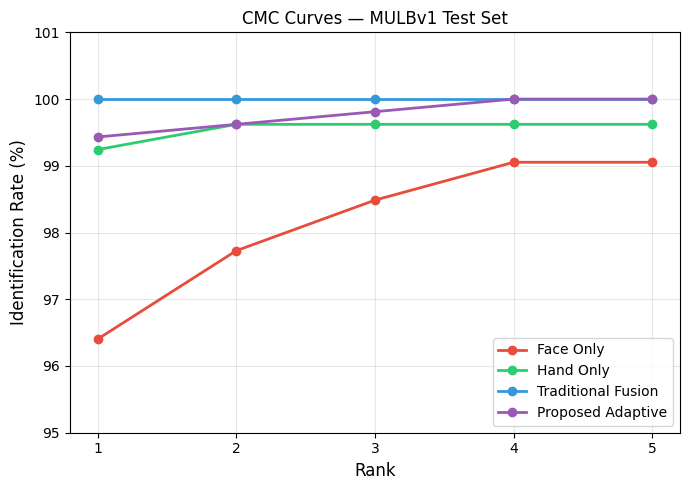

Figure 10 saved.


In [24]:
# ---- Figure: CMC Curves (Figure 10) ----
systems_cmc = [
    ("Face Only",          face_preds),
    ("Hand Only",          hand_preds),
    ("Traditional Fusion", face_preds * hand_preds),
    ("Proposed Adaptive",  proposed_scores),
]
colors = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6']

fig, ax = plt.subplots(figsize=(7, 5))
for (name, scores), color in zip(systems_cmc, colors):
    cmc = [rank_n(scores, y_true, r) for r in range(1, 6)]
    ax.plot(range(1, 6), cmc, 'o-', label=name, color=color, linewidth=2, markersize=6)

ax.set_xlabel('Rank', fontsize=12)
ax.set_ylabel('Identification Rate (%)', fontsize=12)
ax.set_title('CMC Curves — MULBv1 Test Set', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, 6))
ax.set_ylim([95, 101])
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Figure10_CMC.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 10 saved.")

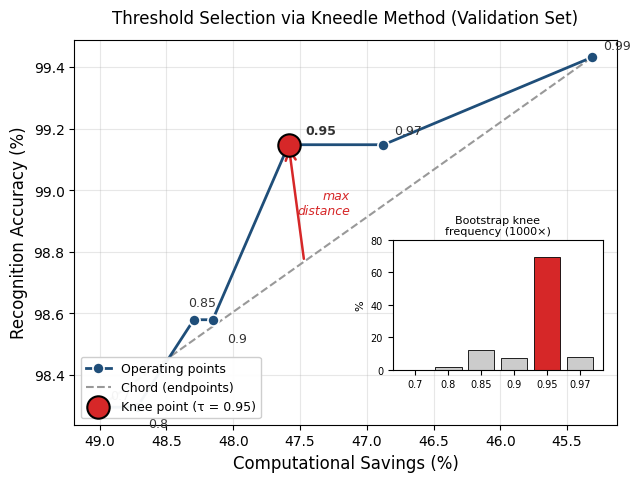

Kneedle figure saved.


In [25]:
# ---- Figure: Threshold Kneedle (Figure X) ----
taus_kneedle = [0.70, 0.80, 0.85, 0.90, 0.95, 0.97, 0.99]
A_val_k, S_val_k = metrics_at(face_preds_val, hand_preds_val, y_val, taus_kneedle)

Sn = (S_val_k - S_val_k.min()) / (S_val_k.max() - S_val_k.min())
An = (A_val_k - A_val_k.min()) / (A_val_k.max() - A_val_k.min())
x1, y1 = Sn[0], An[0]; x2, y2 = Sn[-1], An[-1]
den = np.sqrt((y2-y1)**2 + (x2-x1)**2)
dists = [abs((y2-y1)*Sn[i]-(x2-x1)*An[i]+x2*y1-y2*x1)/den for i in range(len(taus_kneedle))]
knee_idx = int(np.argmax(dists))

from matplotlib.patches import FancyArrowPatch
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(S_val_k, A_val_k, 'o-', color='#1f4e79', linewidth=2, markersize=8,
        markerfacecolor='#1f4e79', markeredgecolor='white', markeredgewidth=1.2, zorder=3,
        label='Operating points')
ax.plot([S_val_k[0], S_val_k[-1]], [A_val_k[0], A_val_k[-1]], '--',
        color='#999999', linewidth=1.5, zorder=2, label='Chord (endpoints)')
ax.scatter([S_val_k[knee_idx]], [A_val_k[knee_idx]], s=260,
           facecolor='#d62728', edgecolor='black', linewidth=1.5, zorder=5,
           label=f'Knee point (τ = {taus_kneedle[knee_idx]})')

px, py = S_val_k[knee_idx], A_val_k[knee_idx]
dx, dy = S_val_k[-1]-S_val_k[0], A_val_k[-1]-A_val_k[0]
t = ((px-S_val_k[0])*dx + (py-A_val_k[0])*dy) / (dx*dx + dy*dy)
fx, fy = S_val_k[0]+t*dx, A_val_k[0]+t*dy
arrow = FancyArrowPatch((fx, fy), (px, py), arrowstyle='->', color='#d62728',
                         linewidth=1.8, mutation_scale=18, zorder=4)
ax.add_patch(arrow)
ax.text((fx+px)/2-0.4, (fy+py)/2, 'max\ndistance',
        fontsize=9, color='#d62728', ha='right', va='center', style='italic')

label_offsets = {0.70:(8,6), 0.80:(8,-14), 0.85:(-4,10), 0.90:(10,-16),
                 0.95:(12,8), 0.97:(8,8), 0.99:(8,6)}
for i, tau in enumerate(taus_kneedle):
    xo, yo = label_offsets.get(tau, (8, 6))
    ax.annotate(f'{tau}', (S_val_k[i], A_val_k[i]),
                textcoords="offset points", xytext=(xo, yo),
                fontsize=9, color='#333333',
                fontweight='bold' if i == knee_idx else 'normal')

ax.set_xlabel('Computational Savings (%)', fontsize=12)
ax.set_ylabel('Recognition Accuracy (%)', fontsize=12)
ax.set_title('Threshold Selection via Kneedle Method (Validation Set)', fontsize=12, pad=12)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower left', fontsize=9, framealpha=0.95)
ax.invert_xaxis()

# Bootstrap inset
boot_thr  = [0.70, 0.80, 0.85, 0.90, 0.95, 0.97]
boot_freq = [knee_counts.get(t, 0)/10 for t in boot_thr]
inset = fig.add_axes([0.58, 0.22, 0.30, 0.26])
colors_bar = ['#d62728' if t == 0.95 else '#cccccc' for t in boot_thr]
inset.bar([str(t) for t in boot_thr], boot_freq, color=colors_bar,
          edgecolor='black', linewidth=0.6)
inset.set_title('Bootstrap knee\nfrequency (1000×)', fontsize=8, pad=4)
inset.set_ylabel('%', fontsize=8)
inset.tick_params(axis='both', labelsize=7)
inset.set_ylim(0, 80)

plt.savefig('/content/drive/MyDrive/Figure_Kneedle.png', dpi=300, bbox_inches='tight')
plt.show()
print("Kneedle figure saved.")